# **🎬 Movie Rating Prediction Using Machine Learning**
### **By--Amit Kumar**

# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# **Load Dataset**

In [9]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

# **Dataset Overview**

In [10]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [11]:
df.shape

(15509, 10)

In [12]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


# **Missing Values**

In [14]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

# **Data Cleaning**

In [15]:
df = df.dropna(
    subset=['Rating']
)

In [16]:
df['Genre'] = df['Genre'].fillna('Unknown')

df['Director'] = df['Director'].fillna('Unknown')

df['Actor 1'] = df['Actor 1'].fillna('Unknown')

# **Statistical Summary**

In [17]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


# **Rating Distribution**

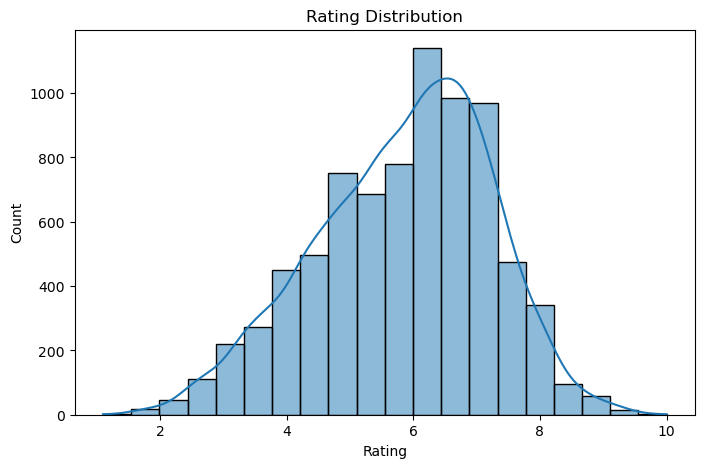

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")

plt.show()

# **Top 10 Genres**

In [19]:
top_genres = df['Genre'].value_counts().head(10)

top_genres

Genre
Drama                     1177
Drama, Romance             447
Action, Crime, Drama       417
Action                     417
Drama, Family              291
Action, Drama              271
Comedy                     259
Comedy, Drama              239
Romance                    234
Comedy, Drama, Romance     213
Name: count, dtype: int64

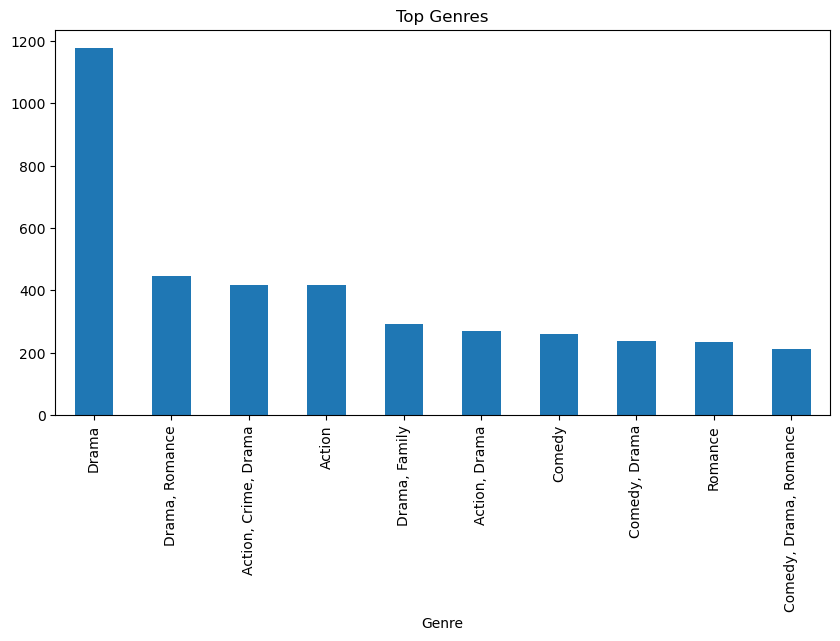

In [20]:
plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title("Top Genres")

plt.show()

# **Top 10 Directors**

In [21]:
top_directors = df['Director'].value_counts().head(10)

top_directors

Director
Mahesh Bhatt            47
David Dhawan            43
Hrishikesh Mukherjee    42
Shakti Samanta          39
Kanti Shah              38
Rama Rao Tatineni       34
Basu Chatterjee         34
Ram Gopal Varma         34
Shibu Mitra             33
Vikram Bhatt            33
Name: count, dtype: int64

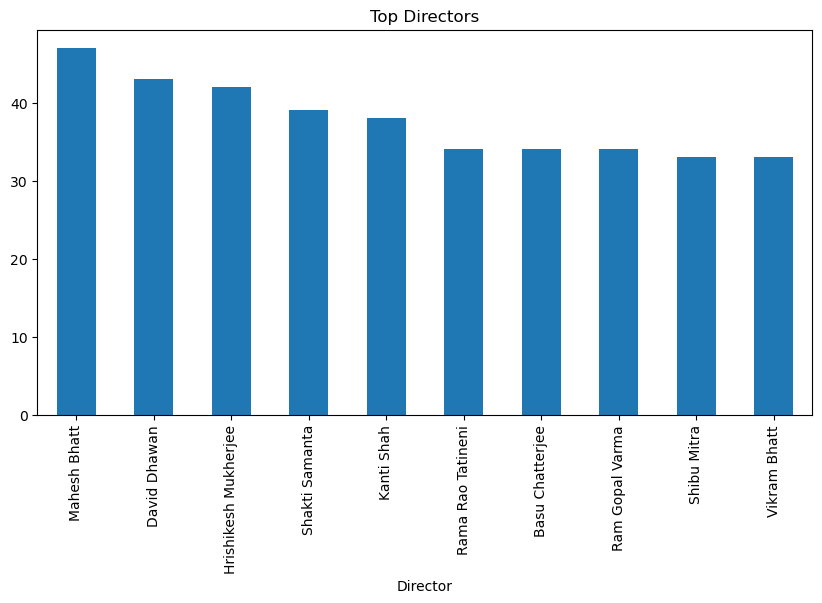

In [22]:
plt.figure(figsize=(10,5))

top_directors.plot(kind='bar')

plt.title("Top Directors")

plt.show()

# **Top 10 Highest Rated Movies**

In [23]:
top_movies = df[
    ['Name','Rating']
].sort_values(
    by='Rating',
    ascending=False
).head(10)

top_movies

,Name,Rating
8339,Love Qubool Hai,10.0
5410,Half Songs,9.7
2563,Breed,9.6
11704,Ram-Path,9.4
14222,The Reluctant Crime,9.4
6852,June,9.4
5077,Gho Gho Rani,9.4
1314,Ashok Vatika,9.3
5125,God of gods,9.3
12673,Secrets of Sinauli,9.3


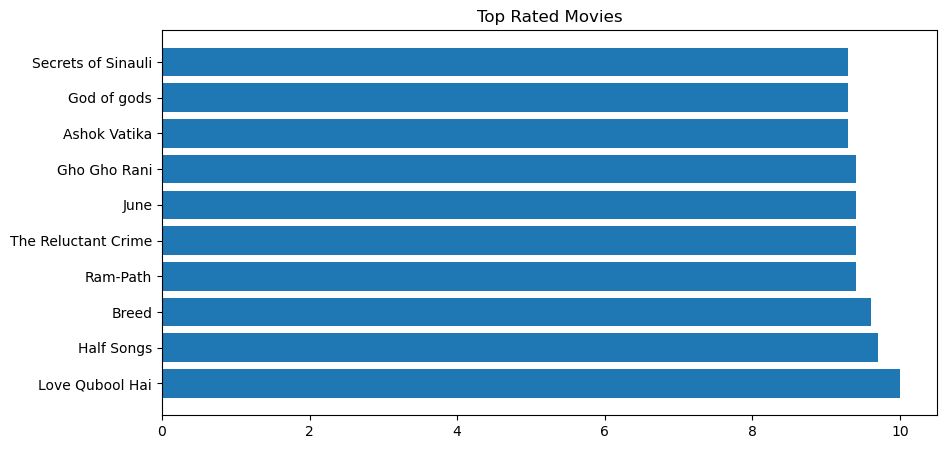

In [24]:
plt.figure(figsize=(10,5))

plt.barh(
    top_movies['Name'],
    top_movies['Rating']
)

plt.title(
    "Top Rated Movies"
)

plt.show()

# **Rating vs Votes**

In [25]:
df['Votes'] = df['Votes'].astype(str)

df['Votes'] = df['Votes'].str.replace(
    ',',
    ''
)

df['Votes'] = pd.to_numeric(
    df['Votes'],
    errors='coerce'
)

df['Votes'] = df['Votes'].fillna(0)

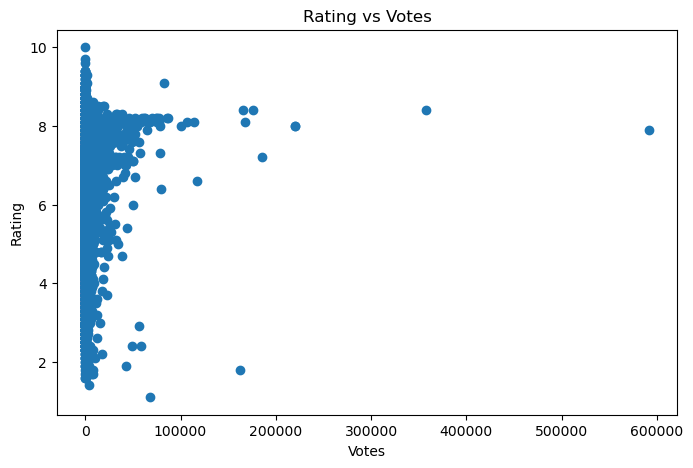

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Votes'],
    df['Rating']
)

plt.xlabel("Votes")

plt.ylabel("Rating")

plt.title(
    "Rating vs Votes"
)

plt.show()

# **Correlation Heatmap**

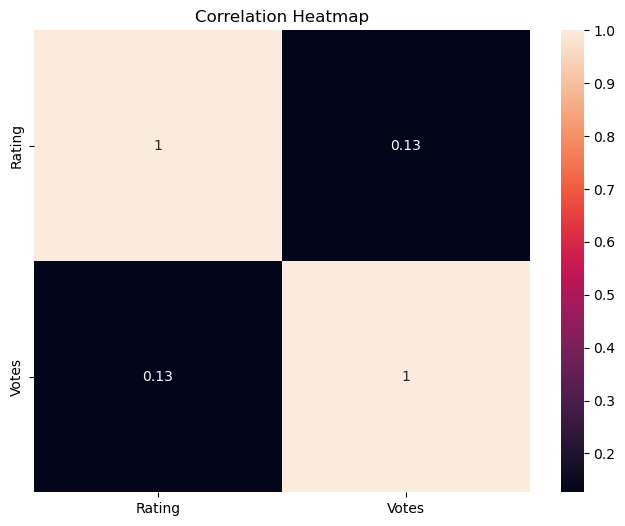

In [27]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# **Label Encoding**

In [28]:
encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(
    df['Genre']
)

df['Director'] = encoder.fit_transform(
    df['Director']
)

df['Actor 1'] = encoder.fit_transform(
    df['Actor 1']
)

# **Feature Selection**

In [29]:
features = [
    'Genre',
    'Director',
    'Actor 1',
    'Votes'
]

X = df[features]

y = df['Rating']

# **Train Test Split**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Train Model**

In [31]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# **Prediction**

In [32]:
y_pred = model.predict(
    X_test
)

# **MAE**

In [33]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.9650663720538721


# **RMSE**

In [34]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

RMSE: 1.2295501788085728


# **R² Score**

In [35]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:", r2)

R2 Score: 0.18683398667534667


# **Actual vs Predicted Graph**

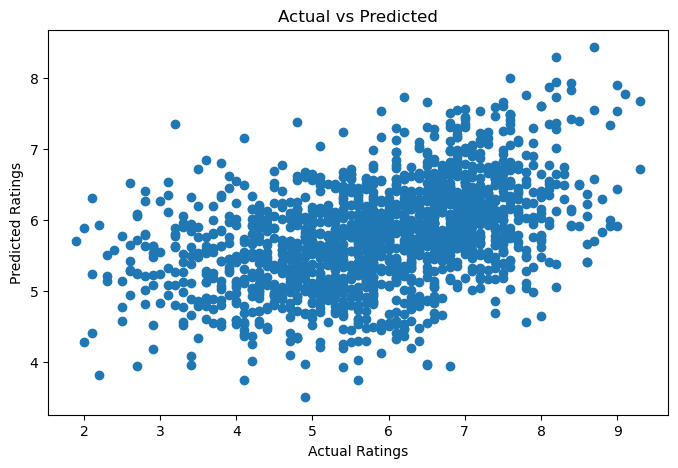

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Ratings"
)

plt.ylabel(
    "Predicted Ratings"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

# **Feature Importance**

In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance

,Feature,Importance
0,Genre,0.224913
1,Director,0.244130
2,Actor 1,0.253080
3,Votes,0.277876


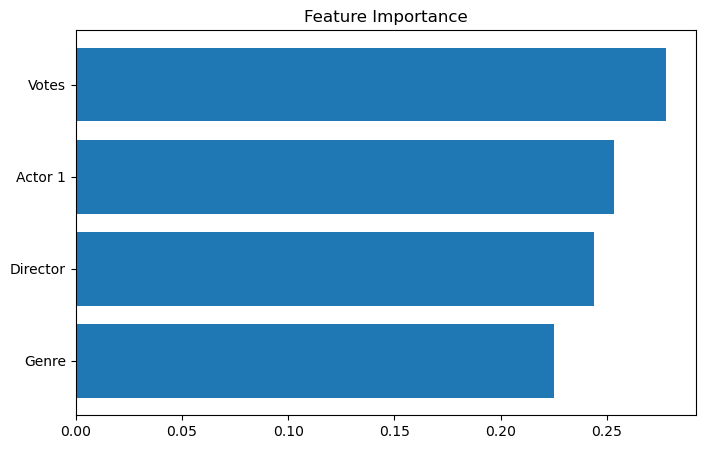

In [38]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title(
    "Feature Importance"
)

plt.show()

# **Sample Prediction**

In [40]:
sample = pd.DataFrame({
    'Genre':[2],
    'Director':[17],
    'Actor 1':[10],
    'Votes':[3000]
})

prediction = model.predict(
    sample
)

print(
    "Predicted Rating:",
    round(
        prediction[0],
        2
    )
)

Predicted Rating: 4.5
